In [4]:
import matplotlib.pyplot as plt
from PIL import Image

# File paths
image_paths = [
    r"D:\Papers\Braille\braille_char\v8n\BoxPR_curve.png",
    r"D:\Papers\Braille\braille_char\v8n\BoxR_curve.png",
    r"D:\Papers\Braille\braille_char\v8n\BoxF1_curve.png",
    r"D:\Papers\Braille\braille_char\v8n\BoxP_curve.png"
]

# Titles for each subplot
titles = ["PR Curve", "Recall Curve", "F1 Score Curve", "Precision Curve"]

# Create a 2x2 subplot with higher DPI
fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=300)
fig.tight_layout(pad=5)

# Loop through images and plot them
for idx, ax in enumerate(axes.flat):
    img = Image.open(image_paths[idx])
    ax.imshow(img)
    ax.set_title(titles[idx], fontsize=14, fontweight='bold')
    ax.axis('off')

# Save the collage with high DPI and PNG format
output_path = r"D:\Papers\Braille\braille_char\v8n\BoxCollage_HQ.png"
plt.savefig(output_path, bbox_inches='tight', dpi=300, format='png')
plt.close()

print(f"High-quality collage saved to: {output_path}")

High-quality collage saved to: D:\Papers\Braille\braille_char\v8n\BoxCollage_HQ.png


In [8]:
from PIL import Image, ImageDraw, ImageFont

# File paths
image_paths = [
    r"D:\Papers\Braille\braille_char\v8n\confusion_matrix.png",
    r"D:\Papers\Braille\braille_char\v8n\confusion_matrix_normalized.png"
]

titles = ["Confusion Matrix", "Normalized Confusion Matrix"]

# Load images
images = [Image.open(path) for path in image_paths]

# Font settings
try:
    font = ImageFont.truetype("arial.ttf", size=60)  # bigger for readability
except:
    font = ImageFont.load_default()

# Title height
title_height = 100
images_with_titles = []
for img, title in zip(images, titles):
    w, h = img.size
    canvas = Image.new("RGB", (w, h + title_height), "white")
    draw = ImageDraw.Draw(canvas)
    # Centered title
    draw.text((w // 2, title_height // 2), title, font=font, fill="black", anchor="mm")
    canvas.paste(img, (0, title_height))
    images_with_titles.append(canvas)

# Combine horizontally (1×2) at full resolution
total_width = sum(img.width for img in images_with_titles)
max_height = max(img.height for img in images_with_titles)
collage = Image.new("RGB", (total_width, max_height), "white")

x_offset = 0
for img in images_with_titles:
    collage.paste(img, (x_offset, 0))
    x_offset += img.width

# Save with high DPI (so it doesn’t get squished in paper)
output_path = r"D:\Papers\Braille\braille_char\v8n\ConfusionMatrixCollage_HQ_1x2.png"
collage.save(output_path, dpi=(300, 300))

print(f"High-quality 1×2 collage saved to: {output_path}")


High-quality 1×2 collage saved to: D:\Papers\Braille\braille_char\v8n\ConfusionMatrixCollage_HQ_1x2.png


In [7]:
import pandas as pd

# Load the CSV
df = pd.read_csv(r"D:\Papers\Braille\braille_char\v8n\results.csv")

# Select target epochs
target_epochs = [1, 25, 50, 75, 100]
filtered = df[df['epoch'].isin(target_epochs)]

# Choose key columns to keep
columns_to_keep = [
    'epoch', 'time',
    'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
    'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
    'metrics/precision(B)', 'metrics/recall(B)',
    'metrics/mAP50(B)', 'metrics/mAP50-95(B)'
]

# Create a clean DataFrame
clean_df = filtered[columns_to_keep].copy()

# Optional: round floats for readability
float_cols = clean_df.select_dtypes(include='float').columns
clean_df[float_cols] = clean_df[float_cols].round(4)

# Save to new CSV
output_path = r"D:\Papers\Braille\braille_char\v8n\results_summary.csv"
clean_df.to_csv(output_path, index=False)

print(f"Summary saved to: {output_path}")

Summary saved to: D:\Papers\Braille\braille_char\v8n\results_summary.csv


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sample data
data = {
    'epoch': [1, 25, 50, 75, 100],
    'time': [187.076, 4428.54, 8850.52, 13275.3, 17723],
    'train/box_loss': [1.7527, 0.9518, 0.8533, 0.7799, 0.671],
    'train/cls_loss': [3.8302, 0.6944, 0.5767, 0.5068, 0.3739],
    'train/dfl_loss': [1.367, 1.0044, 0.9562, 0.92, 0.8921],
    'val/box_loss': [1.5974, 0.833, 0.7462, 0.7067, 0.684],
    'val/cls_loss': [2.7673, 0.5277, 0.438, 0.3856, 0.3747],
    'val/dfl_loss': [1.4014, 0.991, 0.9396, 0.9044, 0.8938],
    'metrics/precision(B)': [0.2513, 0.9288, 0.9503, 0.958, 0.9602],
    'metrics/recall(B)': [0.1729, 0.9488, 0.9664, 0.9702, 0.9726],
    'metrics/mAP50(B)': [0.1569, 0.9642, 0.9791, 0.983, 0.9846],
    'metrics/mAP50-95(B)': [0.0919, 0.743, 0.78, 0.7963, 0.8036]
}

df = pd.DataFrame(data)

# Metrics to plot
metrics = [
    'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
    'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
    'metrics/precision(B)', 'metrics/recall(B)',
    'metrics/mAP50(B)', 'metrics/mAP50-95(B)'
]

# Set dark-matching color palette
palette = sns.color_palette("dark", len(metrics))

# Create 2×5 subplot grid
fig, axes = plt.subplots(2, 5, figsize=(20, 8), dpi=300)
axes = axes.flatten()

# Plot each metric
for i, metric in enumerate(metrics):
    ax = axes[i]
    color = palette[i]
    ax.plot(df['epoch'], df[metric], marker='o', color=color, linewidth=2)
    
    # Annotate each point
    for x, y in zip(df['epoch'], df[metric]):
        ax.text(x, y + 0.01, f"{y:.3f}", ha='center', va='bottom', fontsize=8)
    
    ax.set_title(metric.replace('/', ' → '), fontsize=10, fontweight='bold')
    ax.set_xlabel("Epoch", fontsize=9)
    ax.set_ylabel("Value", fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)

# Final layout and save
plt.tight_layout()
output_path = r"D:\Papers\Braille\braille_char\v8n\MetricCollage_2x5_HQ.png"
plt.savefig(output_path)
plt.close()

print(f"High-quality 2×5 collage saved to: {output_path}")

High-quality 2×5 collage saved to: D:\Papers\Braille\braille_char\v8n\MetricCollage_2x5_HQ.png


In [10]:
from PIL import Image

# File paths
image_paths = [
    r"D:\Papers\Braille\braille_char\v8n\val_batch0_labels.jpg",
    r"D:\Papers\Braille\braille_char\v8n\val_batch0_pred.jpg",
    r"D:\Papers\Braille\braille_char\v8n\val_batch1_labels.jpg",
    r"D:\Papers\Braille\braille_char\v8n\val_batch1_pred.jpg",
    r"D:\Papers\Braille\braille_char\v8n\val_batch2_labels.jpg",
    r"D:\Papers\Braille\braille_char\v8n\val_batch2_pred.jpg"
]

# Load images
images = [Image.open(path) for path in image_paths]

# Ensure all images are the same size (based on the first image)
base_width, base_height = images[0].size
uniform_images = [img.resize((base_width, base_height), Image.LANCZOS) for img in images]

# Create collage canvas
cols, rows = 3, 2
collage_width = cols * base_width
collage_height = rows * base_height
collage = Image.new("RGB", (collage_width, collage_height), "white")

# Paste images into grid
for idx, img in enumerate(uniform_images):
    x = (idx % cols) * base_width
    y = (idx // cols) * base_height
    collage.paste(img, (x, y))

# Save collage in HD
output_path = r"D:\Papers\Braille\braille_char\v8n\ValBatchCollage_HD.jpg"
collage.save(output_path, format='JPEG', quality=100, subsampling=0)

print(f"HD collage saved to: {output_path}")

HD collage saved to: D:\Papers\Braille\braille_char\v8n\ValBatchCollage_HD.jpg


In [11]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import re

# Folder containing images
folder_path = r"C:\Users\mogno\Project\detected_characters_focused_rpn_grid_20250915_010608\crops"

# Get image file paths
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
image_files.sort()

# Grid size
cols = 8
rows = (len(image_files) + cols - 1) // cols
fig_width = cols * 2
fig_height = rows * 2

# Create subplot grid
fig, axes = plt.subplots(rows, cols, figsize=(fig_width, fig_height), dpi=300)
axes = axes.flatten()

# Plot each image with alphabetic label
for i, ax in enumerate(axes):
    if i < len(image_files):
        img_path = os.path.join(folder_path, image_files[i])
        img = Image.open(img_path)

        # Extract alphabetic characters from filename (excluding extension)
        base_name = os.path.splitext(image_files[i])[0]
        label = ''.join(re.findall(r'[A-Za-z]+', base_name))

        ax.imshow(img)
        ax.set_title(label, fontsize=20)
    ax.axis('off')

# Remove unused axes
for j in range(len(image_files), len(axes)):
    axes[j].axis('off')

# Save collage
output_path = os.path.join(folder_path, "CropsCollage_AlphabetOnly_HD.png")
plt.tight_layout()
plt.savefig(output_path)
plt.close()

print(f"Collage saved to: {output_path}")

Collage saved to: C:\Users\mogno\Project\detected_characters_focused_rpn_grid_20250915_010608\crops\CropsCollage_AlphabetOnly_HD.png


In [5]:
import os
import re
from PIL import Image, ImageDraw, ImageFont

# ================= CONFIG =================
folder_path = r"C:\Users\mogno\Project\detected_characters_focused_rpn_grid_20250915_010608\grid_visualizations"
output_path = os.path.join(folder_path, "GridCollage_Custom_8_8_7_HD.jpg")
padding = 20   # space between images
font_size = 10 # slightly bigger font
label_margin = 8  # gap between image bottom and text
# ==========================================

# Load and sort image files
image_files = sorted([
    f for f in os.listdir(folder_path)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])

if not image_files:
    raise ValueError("No image files found in folder.")

# Load images
images = [Image.open(os.path.join(folder_path, f)) for f in image_files]

# Resize all images to same size (based on first image)
img_w, img_h = images[0].size
resized = [img.resize((img_w, img_h), Image.LANCZOS) for img in images]

# Chunk into rows: 8 + 8 + 7
rows = [resized[:8], resized[8:16], resized[16:]]
row_files = [image_files[:8], image_files[8:16], image_files[16:]]

# Load font
try:
    font = ImageFont.truetype("arial.ttf", size=font_size)
except:
    font = ImageFont.load_default()

# Precompute text height
dummy_draw = ImageDraw.Draw(resized[0])
text_height = dummy_draw.textbbox((0, 0), "Sample", font=font)[3]

# Each row height = image height + label height + margin + padding
row_heights = [(img_h + label_margin + text_height + padding)] * len(rows)
canvas_width = 8 * img_w + 7 * padding
canvas_height = sum(row_heights)

collage = Image.new("RGB", (canvas_width, canvas_height), "white")

# Paste rows
y_offset = 0
for row_idx, (row_imgs, row_names) in enumerate(zip(rows, row_files)):
    if row_idx < 2:
        # First two rows: left-aligned
        x_offset = 0
    else:
        # Third row: centered
        total_row_width = len(row_imgs) * img_w + (len(row_imgs) - 1) * padding
        x_offset = (canvas_width - total_row_width) // 2

    for img, fname in zip(row_imgs, row_names):
        collage.paste(img, (x_offset, y_offset))

        # Draw label below the image
        draw = ImageDraw.Draw(collage)
        base_name = os.path.splitext(fname)[0]

        # Extract first alphabet
        match = re.search(r'[A-Za-z]', base_name)
        if match:
            label = match.group(0).upper() + "_grid"
        else:
            label = base_name

        text_x = x_offset + img_w // 2
        text_y = y_offset + img_h + label_margin
        draw.text((text_x, text_y), label, font=font, fill="black", anchor="ma")

        x_offset += img_w + padding

    y_offset += img_h + label_margin + text_height + padding

# Save collage
collage.save(output_path, format='JPEG', quality=300, subsampling=0)
print(f"✅ Custom collage saved to: {output_path}")

✅ Custom collage saved to: C:\Users\mogno\Project\detected_characters_focused_rpn_grid_20250915_010608\grid_visualizations\GridCollage_Custom_8_8_7_HD.jpg


In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Folder containing heatmap images
folder_path = r"D:\Papers\Braille\train_evaluation\heatmaps"

# Get image file paths
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
image_files.sort()

# Grid layout: 4 rows × 5 columns
cols = 5
rows = 4
fig_width = cols * 2.5
fig_height = rows * 2.5

# Create subplot grid
fig, axes = plt.subplots(rows, cols, figsize=(fig_width, fig_height), dpi=300)
axes = axes.flatten()

# Plot each image
for i, ax in enumerate(axes):
    if i < len(image_files):
        img_path = os.path.join(folder_path, image_files[i])
        img = Image.open(img_path)
        ax.imshow(img)
    ax.axis('off')

# Remove unused axes (if any)
for j in range(len(image_files), len(axes)):
    axes[j].axis('off')

# Save collage
output_path = os.path.join(folder_path, "HeatmapCollage_5x4_HD.png")
plt.tight_layout()
plt.savefig(output_path)
plt.close()

print(f"Collage saved to: {output_path}")

Collage saved to: D:\Papers\Braille\train_evaluation\heatmaps\HeatmapCollage_5x4_HD.png


In [6]:
import os
from PIL import Image, ImageDraw

# Folder containing images
folder_path = r"D:\Papers\Braille\visualizations"

# Get image file paths
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
image_files.sort()

# Load images
images = [Image.open(os.path.join(folder_path, f)) for f in image_files]

# Grid layout: 2 rows × 5 columns
cols, rows = 2, 5
thumb_w, thumb_h = images[0].size  # assuming all same size

# Line settings
line_thickness = 3   # pixels
line_color = "black"

# Add space for separator lines
collage_w = cols * thumb_w + (cols - 1) * line_thickness
collage_h = rows * thumb_h
collage = Image.new("RGB", (collage_w, collage_h), "white")

# Paste images into grid
for i, img in enumerate(images[:cols * rows]):  # only first 10 images
    col = i % cols
    row = i // cols
    x = col * (thumb_w + line_thickness)
    y = row * thumb_h
    collage.paste(img, (x, y))

# Draw vertical separator lines
draw = ImageDraw.Draw(collage)
for c in range(1, cols):
    x = c * thumb_w + (c - 1) * line_thickness
    draw.rectangle([x, 0, x + line_thickness - 1, collage_h], fill=line_color)

# Save with 300 DPI
output_path = os.path.join(folder_path, "VisualizationsCollage_2x5_withLines.png")
collage.save(output_path, dpi=(300, 300))

print(f"Collage saved to: {output_path}")


Collage saved to: D:\Papers\Braille\visualizations\VisualizationsCollage_2x5_withLines.png


In [7]:
import os
import json
import pandas as pd

# Folder path
folder = r"D:\Papers\Braille\Attention-CNN\v4\_output_\results\final_results\false"

records = []

def fuzzy_score(pred, true):
    matches = sum(p == t for p, t in zip(pred, true))
    return matches / len(pred)

# Process each JSON
for file in os.listdir(folder):
    if file.endswith(".json"):
        path = os.path.join(folder, file)
        with open(path, "r") as f:
            data = json.load(f)
        
        pred = data["predicted_class"]
        true = data["true_class"]
        score = fuzzy_score(data["predicted_grid"], data["true_grid"])
        
        records.append({
            "True Class": true,
            "Predicted Class": pred,
            "Confidence": data["confidence"],
            "Fuzzy Score": score
        })

# Convert to DataFrame
df = pd.DataFrame(records)

# Group misclassifications
summary = (
    df.groupby(["True Class", "Predicted Class"])
    .agg(
        Count=("Fuzzy Score", "count"),
        Avg_Fuzzy=("Fuzzy Score", "mean"),
        Avg_Conf=("Confidence", "mean")
    )
    .reset_index()
    .sort_values(by="Count", ascending=False)
)

# Save summary table
out_path = os.path.join(folder, "misclassification_summary.csv")
summary.to_csv(out_path, index=False)

print(f"Summary saved at {out_path}")
print(summary.head(15))


Summary saved at D:\Papers\Braille\Attention-CNN\v4\_output_\results\final_results\false\misclassification_summary.csv
   True Class Predicted Class  Count  Avg_Fuzzy  Avg_Conf
20          E               A      5   0.833333  0.993038
21          E               D      3   0.833333  0.985721
60          N               I      3   0.388889  0.901384
1           A               C      3   0.833333  0.979478
25          E               O      3   0.888889  0.863078
31          G               A      3   0.444444  0.781329
79          S               A      3   0.444444  0.677517
61          N               T      3   0.666667  0.820686
44          J               A      2   0.333333  0.983248
36          I               A      2   0.500000  0.983248
34          H               A      2   0.666667  0.983248
84          T               M      2   0.583333  0.958369
49          K               O      2   0.833333  0.663126
27          F               A      2   0.666667  0.983248
39         

Saved side-by-side training curves at: C:\Users\mogno\Downloads\training_curves_side_by_side.png


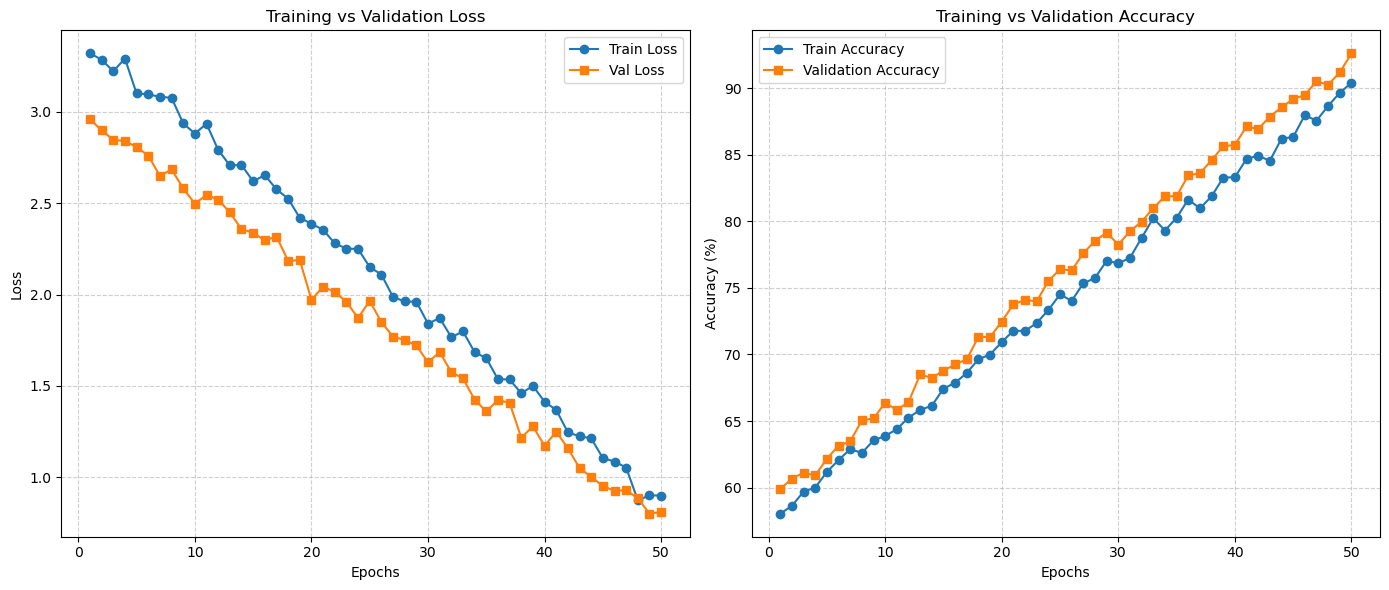

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV
file_path = r"C:\Users\mogno\Downloads\training_log_50_epochs.csv"
df = pd.read_csv(file_path, sep=",")  # Change to sep="\t" if tab-separated

# ===================== SIDE-BY-SIDE PLOTS =====================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

# ---- LOSS CURVE ----
axes[0].plot(df["Epoch"], df["Train Loss"], label="Train Loss", marker="o")
axes[0].plot(df["Epoch"], df["Val Loss"], label="Val Loss", marker="s")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

# ---- ACCURACY CURVE ----
axes[1].plot(df["Epoch"], df["Train Acc (%)"], label="Train Accuracy", marker="o")
axes[1].plot(df["Epoch"], df["Val Acc (%)"], label="Validation Accuracy", marker="s")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Training vs Validation Accuracy")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

# Save in 300 DPI
output_path = r"C:\Users\mogno\Downloads\training_curves_side_by_side.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

print(f"Saved side-by-side training curves at: {output_path}")

plt.show()


In [1]:
from PIL import Image

# File paths
image_paths = [
    r"D:\Papers\Braille\val_evaluation\tsne_2d.png",
    r"D:\Papers\Braille\val_evaluation\tsne_3d.png"
]

# Load images
images = [Image.open(path) for path in image_paths]

# Ensure same height (optional resize)
base_height = max(img.height for img in images)
resized = [img.resize((int(img.width * base_height / img.height), base_height), Image.LANCZOS) for img in images]

# Create collage canvas
total_width = sum(img.width for img in resized)
collage = Image.new("RGB", (total_width, base_height), "white")

# Paste images side by side
x_offset = 0
for img in resized:
    collage.paste(img, (x_offset, 0))
    x_offset += img.width

# Save collage in HD
output_path = r"D:\Papers\Braille\val_evaluation\tSNE_Collage_HD.png"
collage.save(output_path, format='PNG')

print(f"t-SNE collage saved to: {output_path}")

t-SNE collage saved to: D:\Papers\Braille\val_evaluation\tSNE_Collage_HD.png


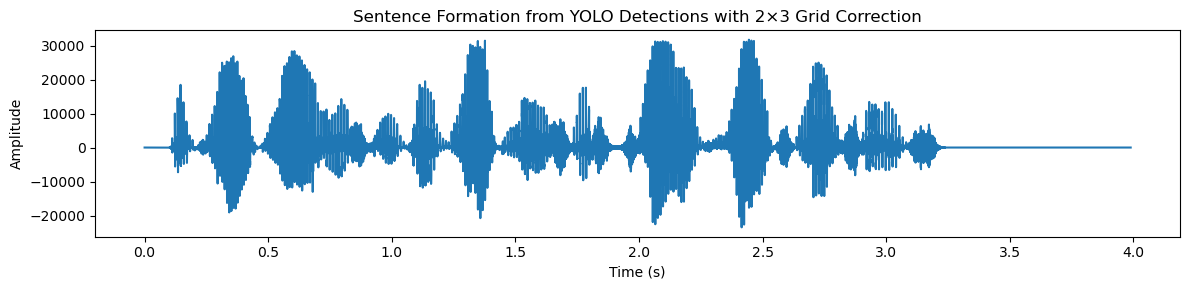

Saved WAV to: speech.wav
Saved waveform image to: waveform.png
Used real TTS (pyttsx3): True


In [2]:
# save as make_tts_waveform.py
import os
sentence = "A great man is who did not lose his child Heart's Mencius"
out_path = "speech.wav"

def generate_with_pyttsx3(text, out):
    import pyttsx3
    engine = pyttsx3.init()
    try:
        engine.setProperty('rate', 150)
    except Exception:
        pass
    engine.save_to_file(text, out)
    engine.runAndWait()
    return os.path.exists(out)

def fallback_synthetic_tts(text, out):
    import numpy as np, wave
    framerate = 22050
    amplitude = 16000
    result = []
    base_map = {c: 300 + (ord(c) % 50) * 10 for c in set(text)}
    words = text.split()
    for word in words:
        for ch in word:
            f = base_map[ch]
            duration = 0.09 + (ord(ch) % 5) * 0.02
            t = np.linspace(0, duration, int(framerate*duration), False)
            envelope = np.sin(np.pi * t / duration)
            tone = envelope * np.sin(2 * np.pi * f * t)
            result.append(tone)
            result.append(np.zeros(int(0.01 * framerate)))
        result.append(np.zeros(int(0.12 * framerate)))
    audio = np.concatenate(result).astype(np.float32)
    audio = audio / (np.max(np.abs(audio)) + 1e-9)
    audio_int16 = (audio * amplitude).astype('<i2')
    with wave.open(out, 'wb') as wf:
        wf.setnchannels(1)
        wf.setsampwidth(2)
        wf.setframerate(framerate)
        wf.writeframes(audio_int16.tobytes())
    return True

used_pyttsx3 = False
success = False
try:
    success = generate_with_pyttsx3(sentence, out_path)
    used_pyttsx3 = success
except Exception:
    success = False

if not success:
    success = fallback_synthetic_tts(sentence, out_path)

# Plot waveform
import wave, numpy as np, matplotlib.pyplot as plt
with wave.open(out_path, 'rb') as wf:
    n_channels = wf.getnchannels()
    sampwidth = wf.getsampwidth()
    framerate = wf.getframerate()
    n_frames = wf.getnframes()
    raw = wf.readframes(n_frames)
    dtype = '<i2' if sampwidth == 2 else None
    audio = np.frombuffer(raw, dtype=dtype)
    if n_channels > 1:
        audio = audio.reshape(-1, n_channels).mean(axis=1)
    times = np.linspace(0, n_frames / framerate, num=audio.shape[0])

plt.figure(figsize=(12,3))
plt.plot(times, audio)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Sentence Formation from YOLO Detections with 2×3 Grid Correction")
plt.tight_layout()
plt.savefig("waveform.png")
plt.show()

print("Saved WAV to:", out_path)
print("Saved waveform image to: waveform.png")
print("Used real TTS (pyttsx3):", used_pyttsx3)

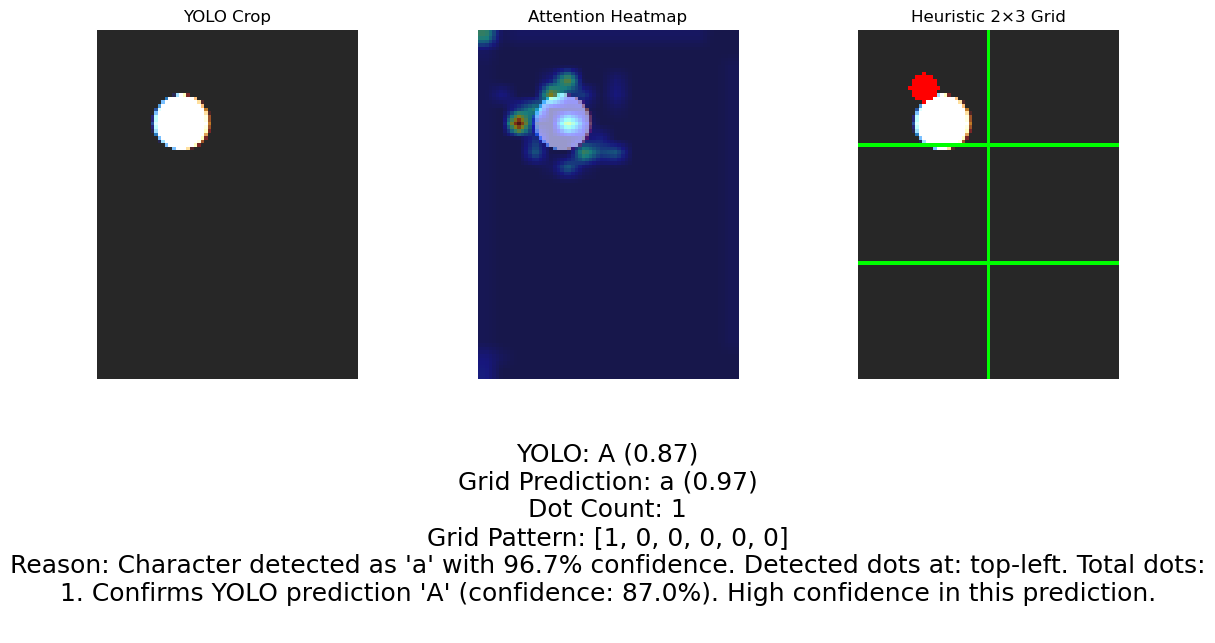

Saved composite visualization at: detected_characters_focused_rpn_grid_20250915_010608/xai_explanations/0004/comprehensive_visualization.png


In [4]:
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Your JSON (replace this with actual dict or load from file)
data = {
  "index": 4,
  "yolo_label": "A",
  "yolo_confidence": 0.8696538805961609,
  "attn_label": "a",
  "attn_confidence": 0.9673771262168884,
  "grid_pattern": [1,0,0,0,0,0],
  "dot_count": 1,
  "reason": "Character detected as 'a' with 96.7% confidence. Detected dots at: top-left. Total dots: 1. Confirms YOLO prediction 'A' (confidence: 87.0%). High confidence in this prediction.",
  "visualization_paths": {
    "crop_path": "detected_characters_focused_rpn_grid_20250915_010608/xai_explanations/0004/crop.png",
    "heatmap_path": "detected_characters_focused_rpn_grid_20250915_010608/xai_explanations/0004/heatmap.png",
    "grid_path": "detected_characters_focused_rpn_grid_20250915_010608/xai_explanations/0004/grid.png",
    "comprehensive_viz_path": "detected_characters_focused_rpn_grid_20250915_010608/xai_explanations/0004/comprehensive_visualization.png"
  }
}

# Load images
crop_img = mpimg.imread(data["visualization_paths"]["crop_path"])
heatmap_img = mpimg.imread(data["visualization_paths"]["heatmap_path"])
grid_img = mpimg.imread(data["visualization_paths"]["grid_path"])

# Create figure
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# Show crop
axs[0].imshow(crop_img)
axs[0].set_title("YOLO Crop")
axs[0].axis("off")

# Show heatmap
axs[1].imshow(heatmap_img)
axs[1].set_title("Attention Heatmap")
axs[1].axis("off")

# Show 2x3 grid
axs[2].imshow(grid_img)
axs[2].set_title("Heuristic 2×3 Grid")
axs[2].axis("off")

# Add metadata as a text box below
metadata = f"""
YOLO: {data['yolo_label']} ({data['yolo_confidence']:.2f})
Grid Prediction: {data['attn_label']} ({data['attn_confidence']:.2f})
Dot Count: {data['dot_count']}
Grid Pattern: {data['grid_pattern']}
Reason: {data['reason']}
"""

plt.figtext(0.5, -0.05, metadata, ha="center", va="top", wrap=True, fontsize=18)

# Adjust layout
plt.tight_layout()
out_path = data["visualization_paths"]["comprehensive_viz_path"]
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, bbox_inches="tight")
plt.show()

print("Saved composite visualization at:", out_path)

In [1]:
from PIL import Image

# Load the image
input_path = r"C:\Users\mogno\Downloads\1.png"
img = Image.open(input_path)

# Save with 300 DPI
output_path = r"C:\Users\mogno\Downloads\1_300dpi.png"
img.save(output_path, dpi=(300, 300))

print(f"Saved 300 DPI image to: {output_path}")

Saved 300 DPI image to: C:\Users\mogno\Downloads\1_300dpi.png
